# **PickleDB: A Dataset for Ball Tracking in PickleBall**

Ronald Dawson Catignas, Malks Mogen David, Lorenzo Alfred Nery, Job Trocino

---

## **Table of Contents**

1. Data Preparation
2. Exploratory Data Analysis
3. Data Preprocessing
4. Model Selection and Training
5. Error Analysis and Model Tuning
6. Model Evaluation

---

## **Prerequisites**

In [ ]:
!pip install -r requirements.txt

In [ ]:
import os
import tarfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
from huggingface_hub import snapshot_download

In [ ]:
repo_path = snapshot_download(repo_id="Renzios/PickleDB", repo_type="dataset")
extract_dir = "./dataset"
os.makedirs(extract_dir, exist_ok=True)

for split in ['train.tar', 'val.tar', 'test.tar']:
    tar_path = os.path.join(repo_path, split)
    if os.path.exists(tar_path):
        with tarfile.open(tar_path, 'r') as tar:
            tar.extractall(path=extract_dir)

---

## **Data Preparation**

To develop object detection models for ball detection in PickleBall matches, a dataset is needed. The data preparation is divided into seven stages as shown in the figure below.

![Data Preparation](figures/data_preparation.svg)

### **Downloading**

Pickleball matches were downloaded from a [**playlist**](https://www.youtube.com/playlist?list=PLP4XKBX8mELQukktGq-kvYwfblr5ri2aG) of professional pickleball match highlights.

### **Filtering**

The matches were filtered to include only videos with a resolution of **1920x1080p** and a frame rate of **30 FPS**.

### **Categorizing**

The matches were categorized based on its **court color (Green, Blue, or Green and Blue)** and the **match type (Singles or Doubles)**.

| ID | Match | Court Color | Match Type |
|:---|:---|:---|:---|
| 1 | Sam Querrey's FIRST Pro Pickleball Match - Highlights vs. Alex Neumann - PPA "The Masters" 2023 | Green | Singles |
| 2 | Rivalry continued - Johns Brothers vs. JW Johnson & Dylan Frazier - Semifinal Match Highlights | Blue | Doubles |
| 3 | Jack Sock captures first Pickleball title with 16 y.o. Anna Leigh Waters - Match Highlightsm| Green | Doubles |
| 4 | PPA North Carolina Open - Newman/Wright vs. Johnson/Frazier - Men's Doubles Gold Medal Highlights | Green | Doubles |
| 5 | PPA North Carolina Open - Waters/Parenteau vs. Stratman/Grechkina - Women's Doubles Gold Highlights | Green | Doubles |
| 6 | PPA North Carolina Open - Tyson McGuffin vs. Federico Staksrud - Men's Singles Gold Medal Highlights | Green | Singles |
| 7 | PPA North Carolina Open - Anna Leigh Waters vs. Lea Jansen - Women's Singles Gold Medal Highlights | Green | Singles |
| 8 | 2023 PPA Newport Beach Men's Doubles GOLD Medal Match Highlights - Johnson/Frazier vs. Newman/Wright | Blue | Doubles |
| 9 | 2023 PPA Newport Beach Women's Doubles GOLD Medal Match Highlights - Kovalova/Smith vs. Bright/Koop | Blue | Doubles |
| 10 | Koller/Irvine vs. Bright/Ignatowich - Mixed Doubles GOLD Medal Match Highlights - PPA Red Rock Open | Blue and Green | Doubles |
| 11 | McGuffin/Long vs. Bar/Johns - Men's Doubles GOLD Medal Match Highlights - PPA Red Rock Open 2023 | Blue and Green | Doubles |
| 12 | Tyson McGuffin vs. Pablo Tellez - GOLD Medal Match Highlights - PPA Red Rock Open 2023 | Blue and Green | Singles |
| 13 | Catherine Parenteau vs. Salome Devidze - GOLD Medal Match Highlights - PPA Red Rock Open 2023 | Blue and Green | Singles |
| 14 | The Masters - Dylan Frazier vs. Federico Staksrud - SEMIFINAL Match Highlights 2023 | Green | Singles |
| 15 | The Masters - Catherine Parenteau vs. Lea Jansen - Semi Final Match Highlights | Green | Singles |
| 16 | The Masters - Ben Johns vs. Federico Staksrud - GOLD Medal Match Highlights 2023 | Green | Singles |
| 17 | The Masters - Anna Leigh Waters vs. Lea Jansen - GOLD Medal Match Highlights 2023 | Green | Singles |
| 18 | The Masters - Tyson McGuffin vs. Christian Alshon - Rd of 16 Match Highlights | Green | Singles |
| 19 | The Masters - Ben Johns vs. Zane Navratil - Round of 16 Match Highlights | Green | Singles ||

### **Sampling**

The matches were sampled by extracting **every 15th frame**.

### **Pruning**

The matches were pruned by removing the **first and last 5 seconds** of each video.

### **Labelling**

The matches were labeled using a **YOLO26L** model fine-tuned for ball detection in PickleBall.

### **Splitting**

The matches were split into train, validation, and test sets using a **stratified, match-level split**.

---

## **Exploratory Data Analysis**

### **Frame Count per Split and Overall**

This section counts the total number of frames in the **train** and **validation** splits, then reports the combined total. The counts are based on image files in each split folder.

In [ ]:
# Paths (ONLY train and val for EDA)
base = Path("PickleDB_YOLO")
image_exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

counts = {}
for split in ["train", "val"]:
    split_dir = base / "images" / split
    n_images = sum(1 for p in split_dir.iterdir() if p.is_file() and p.suffix.lower() in image_exts)
    counts[split] = n_images

overall = counts["train"] + counts["val"]

summary_df = pd.DataFrame(
    {
        "split": ["train", "val", "overall (train + val)"],
        "frame_count": [counts["train"], counts["val"], overall],
    }
)

display(summary_df)

print(f"Train frames: {counts['train']:,}")
print(f"Val frames:   {counts['val']:,}")
print(f"Overall:      {overall:,}")

,split,frame_count
0,train,7467
1,val,1734
2,overall (train + val),9201


Train frames: 7,467
Val frames:   1,734
Overall:      9,201


The split contains **7,467** train frames and **1,734** validation frames, for **9,201** total frames used in this EDA.

### **Image Resolution and Basic Image Properties**

This section summarizes image properties in the **train** and **validation** splits. It reports frame dimensions, common resolutions, aspect ratios, and image formats to verify that image characteristics are consistent across splits.

In [ ]:
# Paths (ONLY train and val for EDA)
base = Path("PickleDB_YOLO")
image_exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

records = []
for split in ["train", "val"]:
    split_dir = base / "images" / split
    for img_path in split_dir.iterdir():
        if not (img_path.is_file() and img_path.suffix.lower() in image_exts):
            continue

        with Image.open(img_path) as img:
            width, height = img.size
            mode = img.mode
            image_format = (img.format or img_path.suffix.replace(".", "")).upper()

        records.append(
            {
                "split": split,
                "file": img_path.name,
                "width": width,
                "height": height,
                "resolution": f"{width}x{height}",
                "aspect_ratio": width / height if height else None,
                "mode": mode,
                "format": image_format,
            }
        )

img_df = pd.DataFrame(records)

# Per-split summary statistics
summary = (
    img_df.groupby("split")
    .agg(
        frame_count=("file", "count"),
        unique_resolutions=("resolution", "nunique"),
        min_width=("width", "min"),
        max_width=("width", "max"),
        min_height=("height", "min"),
        max_height=("height", "max"),
        mean_aspect_ratio=("aspect_ratio", "mean"),
        std_aspect_ratio=("aspect_ratio", "std"),
    )
    .reset_index()
)

# Most common resolution per split
top_resolution = (
    img_df.groupby(["split", "resolution"]).size().reset_index(name="count")
    .sort_values(["split", "count", "resolution"], ascending=[True, False, True])
    .groupby("split")
    .head(1)
    .rename(columns={"resolution": "most_common_resolution", "count": "most_common_resolution_count"})
)

summary = summary.merge(
    top_resolution[["split", "most_common_resolution", "most_common_resolution_count"]],
    on="split",
    how="left",
)

# File format distribution
format_dist = (
    img_df.groupby(["split", "format"]).size().reset_index(name="count")
    .sort_values(["split", "count", "format"], ascending=[True, False, True])
)

display(summary)

,split,frame_count,unique_resolutions,min_width,max_width,min_height,max_height,mean_aspect_ratio,std_aspect_ratio,most_common_resolution,most_common_resolution_count
0,train,7467,1,1920,1920,1080,1080,1.777778,0.0,1920x1080,7467
1,val,1734,1,1920,1920,1080,1080,1.777778,0.0,1920x1080,1734


Both train and validation are consistently **1920x1080** with exactly **1 unique resolution** each, and mean aspect ratio is **1.7778 (16:9)** in both splits. This shows there is no resolution mismatch between splits and preprocessing can use a consistent resize strategy.

### **Class Imbalance (Frames with Visible Pickleball)**

This section checks class imbalance by counting frames with at least one valid pickleball annotation and frames without visible pickleball annotations in the **train** and **validation** splits.

In [ ]:
# Paths (ONLY train and val for EDA)
base = Path("PickleDB_YOLO")
image_exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

rows = []

for split in ["train", "val"]:
    img_dir = base / "images" / split
    lbl_dir = base / "labels" / split

    for img_path in img_dir.iterdir():
        if not (img_path.is_file() and img_path.suffix.lower() in image_exts):
            continue

        label_path = lbl_dir / f"{img_path.stem}.txt"
        has_visible_pickleball = False

        if label_path.exists():
            with open(label_path, "r", encoding="utf-8") as f:
                for line in f:
                    parts = line.strip().split()
                    # YOLO format: class x_center y_center width height
                    if len(parts) >= 5:
                        try:
                            w = float(parts[3])
                            h = float(parts[4])
                            if w > 0 and h > 0:
                                has_visible_pickleball = True
                                break
                        except ValueError:
                            continue

        rows.append(
            {
                "split": split,
                "frame": img_path.name,
                "has_visible_pickleball": has_visible_pickleball,
            }
        )

frame_df = pd.DataFrame(rows)

imbalance_summary = (
    frame_df.groupby("split")
    .agg(
        total_frames=("frame", "count"),
        frames_with_visible_pickleball=("has_visible_pickleball", "sum"),
    )
    .reset_index()
)

imbalance_summary["frames_without_visible_pickleball"] = (
    imbalance_summary["total_frames"] - imbalance_summary["frames_with_visible_pickleball"]
)
imbalance_summary["pct_with_visible_pickleball"] = (
    100 * imbalance_summary["frames_with_visible_pickleball"] / imbalance_summary["total_frames"]
).round(2)
imbalance_summary["pct_without_visible_pickleball"] = (
    100 * imbalance_summary["frames_without_visible_pickleball"] / imbalance_summary["total_frames"]
).round(2)

overall = pd.DataFrame(
    {
        "split": ["overall (train + val)"],
        "total_frames": [imbalance_summary["total_frames"].sum()],
        "frames_with_visible_pickleball": [imbalance_summary["frames_with_visible_pickleball"].sum()],
    }
)
overall["frames_without_visible_pickleball"] = (
    overall["total_frames"] - overall["frames_with_visible_pickleball"]
)
overall["pct_with_visible_pickleball"] = (
    100 * overall["frames_with_visible_pickleball"] / overall["total_frames"]
).round(2)
overall["pct_without_visible_pickleball"] = (
    100 * overall["frames_without_visible_pickleball"] / overall["total_frames"]
).round(2)

imbalance_summary = pd.concat([imbalance_summary, overall], ignore_index=True)

display(imbalance_summary)

for _, r in imbalance_summary.iterrows():
    print(
        f"{r['split']}: "
        f"{int(r['frames_with_visible_pickleball']):,}/{int(r['total_frames']):,} frames with visible pickleball "
        f"({r['pct_with_visible_pickleball']}%)"
    )

,split,total_frames,frames_with_visible_pickleball,frames_without_visible_pickleball,pct_with_visible_pickleball,pct_without_visible_pickleball
0,train,7467,4154,3313,55.63,44.37
1,val,1734,970,764,55.94,44.06
2,overall (train + val),9201,5124,4077,55.69,44.31


train: 4,154/7,467 frames with visible pickleball (55.63%)
val: 970/1,734 frames with visible pickleball (55.94%)
overall (train + val): 5,124/9,201 frames with visible pickleball (55.69%)


Frames with visible pickleball are **4,154/7,467 (55.63%)** in train and **970/1,734 (55.94%)** in val, with overall **5,124/9,201 (55.69%)**. The positive/negative ratio is very similar across splits, so class balance is consistent.

### **Bounding Box Size, Court Color, and Aspect Ratio**

This section analyzes pickleball bounding boxes in **train** and **validation** using YOLO labels. It summarizes bounding box width, height, area, and aspect ratio, then compares these distributions across court colors based on match IDs.

,split,boxes,median_w_px,median_h_px,median_area_px,median_aspect_ratio,mean_aspect_ratio
0,train,4154,16.997009,15.701782,267.860755,0.605608,0.614952
1,val,970,13.010193,12.582650,161.429522,0.575140,0.583590


,split,court_color,boxes,median_w_px,median_h_px,median_area_px,median_aspect_ratio
2,train,Green,3185,16.796874,15.535950,260.679190,0.606698
1,train,Blue and Green,549,17.341613,16.552063,287.265264,0.591398
0,train,Blue,420,18.605652,16.330277,307.776712,0.620208
3,val,Blue,368,12.555389,12.838546,159.802965,0.562593
5,val,Green,318,12.494385,11.758438,146.826911,0.585816
4,val,Blue and Green,284,14.947403,14.359802,214.850280,0.577934


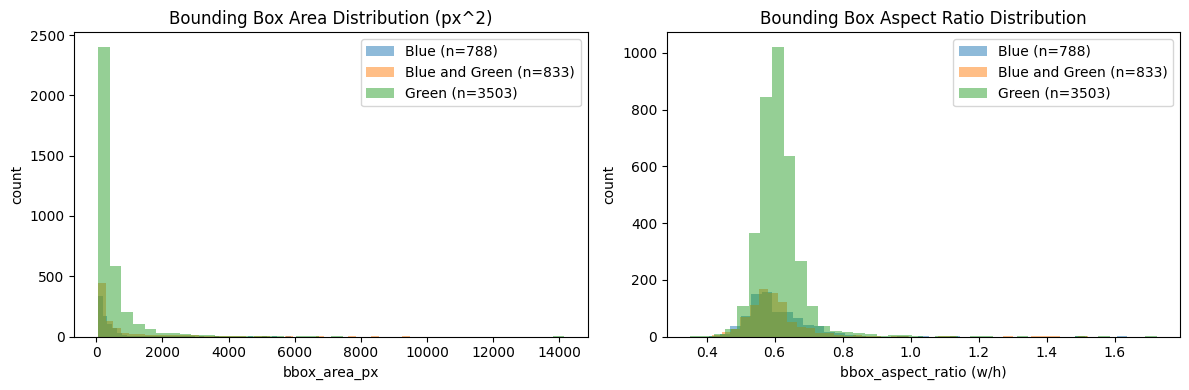

In [ ]:
# Paths (ONLY train and val for EDA)
base = Path("PickleDB_YOLO")
image_exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

# Match ID to court color (from dataset categorization)
court_color_map = {
    1: "Green", 2: "Blue", 3: "Green", 4: "Green", 5: "Green",
    6: "Green", 7: "Green", 8: "Blue", 9: "Blue", 10: "Blue and Green",
    11: "Blue and Green", 12: "Blue and Green", 13: "Blue and Green",
    14: "Green", 15: "Green", 16: "Green", 17: "Green", 18: "Green", 19: "Green",
}

# Collect image dimensions for each frame stem
image_dims = {}
for split in ["train", "val"]:
    img_dir = base / "images" / split
    for img_path in img_dir.iterdir():
        if not (img_path.is_file() and img_path.suffix.lower() in image_exts):
            continue
        with Image.open(img_path) as img:
            image_dims[(split, img_path.stem)] = img.size  # (width, height)

# Parse YOLO labels and compute bbox metrics
bbox_rows = []
for split in ["train", "val"]:
    lbl_dir = base / "labels" / split

    for label_path in lbl_dir.iterdir():
        if not (label_path.is_file() and label_path.suffix.lower() == ".txt"):
            continue

        stem = label_path.stem
        img_size = image_dims.get((split, stem))
        if img_size is None:
            continue

        img_w, img_h = img_size

        # Expected file naming: <match_id>_<frame_id>
        try:
            match_id = int(stem.split("_")[0])
        except (ValueError, IndexError):
            match_id = None

        court_color = court_color_map.get(match_id, "Unknown")

        with open(label_path, "r", encoding="utf-8") as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 5:
                    continue

                try:
                    class_id = int(float(parts[0]))
                    bw = float(parts[3])
                    bh = float(parts[4])
                except ValueError:
                    continue

                if bw <= 0 or bh <= 0:
                    continue

                bbox_rows.append(
                    {
                        "split": split,
                        "frame_stem": stem,
                        "match_id": match_id,
                        "court_color": court_color,
                        "class_id": class_id,
                        "bbox_w_norm": bw,
                        "bbox_h_norm": bh,
                        "bbox_area_norm": bw * bh,
                        "bbox_aspect_ratio": bw / bh,
                        "bbox_w_px": bw * img_w,
                        "bbox_h_px": bh * img_h,
                        "bbox_area_px": (bw * img_w) * (bh * img_h),
                    }
                )

bbox_df = pd.DataFrame(bbox_rows)

if bbox_df.empty:
    print("No valid bounding boxes found in train/val labels.")
else:
    summary_split = (
        bbox_df.groupby("split")
        .agg(
            boxes=("class_id", "count"),
            median_w_px=("bbox_w_px", "median"),
            median_h_px=("bbox_h_px", "median"),
            median_area_px=("bbox_area_px", "median"),
            median_aspect_ratio=("bbox_aspect_ratio", "median"),
            mean_aspect_ratio=("bbox_aspect_ratio", "mean"),
        )
        .reset_index()
    )

    summary_color = (
        bbox_df.groupby(["split", "court_color"])
        .agg(
            boxes=("class_id", "count"),
            median_w_px=("bbox_w_px", "median"),
            median_h_px=("bbox_h_px", "median"),
            median_area_px=("bbox_area_px", "median"),
            median_aspect_ratio=("bbox_aspect_ratio", "median"),
        )
        .reset_index()
        .sort_values(["split", "boxes"], ascending=[True, False])
    )

    display(summary_split)
    display(summary_color)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    for color in sorted(bbox_df["court_color"].dropna().unique()):
        subset = bbox_df[bbox_df["court_color"] == color]
        axes[0].hist(
            subset["bbox_area_px"],
            bins=40,
            alpha=0.5,
            label=f"{color} (n={len(subset)})",
        )
        axes[1].hist(
            subset["bbox_aspect_ratio"],
            bins=40,
            alpha=0.5,
            label=f"{color} (n={len(subset)})",
        )

    axes[0].set_title("Bounding Box Area Distribution (px^2)")
    axes[0].set_xlabel("bbox_area_px")
    axes[0].set_ylabel("count")

    axes[1].set_title("Bounding Box Aspect Ratio Distribution")
    axes[1].set_xlabel("bbox_aspect_ratio (w/h)")
    axes[1].set_ylabel("count")

    for ax in axes:
        ax.legend()

    plt.tight_layout()
    plt.show()

Train boxes are generally larger than val boxes (median area **267.86 px²** vs **161.43 px²**), while median aspect ratios are similar (**0.606** train, **0.575** val), so object shape is stable but scale differs by split. In the histograms, bars farther right indicate larger areas or wider boxes, and higher bars mark more frequent values; visible right-shift in train confirms larger typical box sizes there.

### **Spatial Distribution of Pickleballs (Heatmap)**

This section visualizes where pickleballs usually appear in the frame for the **train** and **validation** splits. It uses YOLO bounding box centers and plots 2D heatmaps in normalized image coordinates.

,split,num_centers
0,train,4154
1,val,970


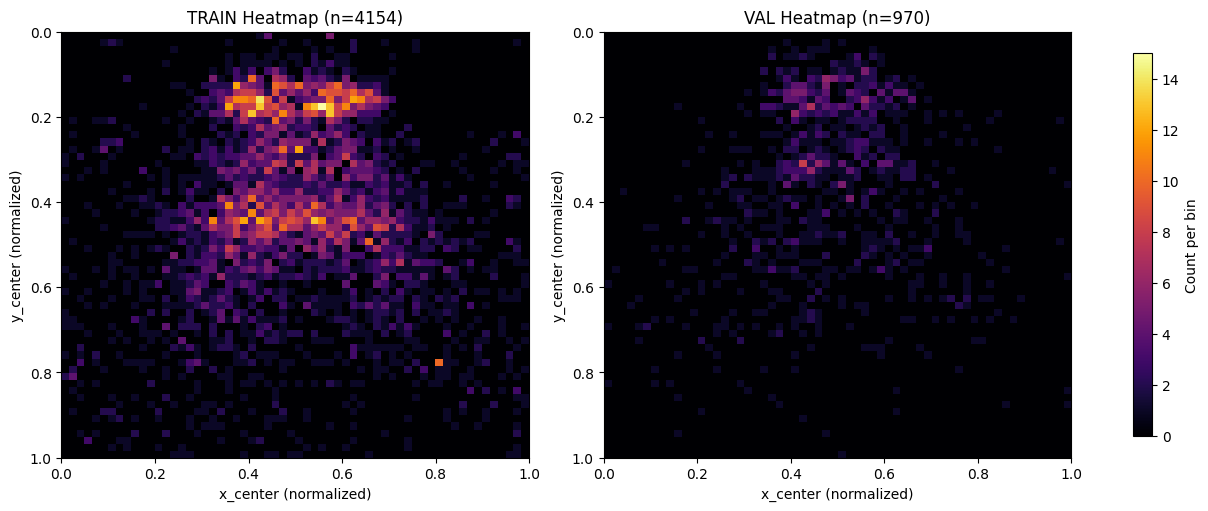

Top 5 populated regions per split (3x3 grid):

TRAIN


,split,y_region,x_region,count
1,train,top,center,1385
4,train,middle,center,1326
5,train,middle,right,432
3,train,middle,left,319
7,train,bottom,center,170



VAL


,split,y_region,x_region,count
10,val,top,center,504
13,val,middle,center,223
12,val,middle,left,77
14,val,middle,right,55
15,val,bottom,left,32


In [ ]:
# Paths (ONLY train and val for EDA)
base = Path("PickleDB_YOLO")

rows = []
for split in ["train", "val"]:
    lbl_dir = base / "labels" / split

    for label_path in lbl_dir.iterdir():
        if not (label_path.is_file() and label_path.suffix.lower() == ".txt"):
            continue

        with open(label_path, "r", encoding="utf-8") as f:
            for line in f:
                parts = line.strip().split()
                # YOLO format: class x_center y_center width height
                if len(parts) < 5:
                    continue

                try:
                    class_id = int(float(parts[0]))
                    x_center = float(parts[1])
                    y_center = float(parts[2])
                    bw = float(parts[3])
                    bh = float(parts[4])
                except ValueError:
                    continue

                # Keep only valid visible boxes inside normalized image bounds
                if bw <= 0 or bh <= 0:
                    continue
                if not (0.0 <= x_center <= 1.0 and 0.0 <= y_center <= 1.0):
                    continue

                rows.append(
                    {
                        "split": split,
                        "class_id": class_id,
                        "x_center": x_center,
                        "y_center": y_center,
                    }
                )

centers_df = pd.DataFrame(rows)

if centers_df.empty:
    print("No valid pickleball centers found in train/val labels.")
else:
    count_summary = centers_df.groupby("split").size().reset_index(name="num_centers")
    display(count_summary)

    bins = 60
    split_order = ["train", "val"]

    # Precompute 2D histograms so both splits use the same color scale.
    heatmaps = {}
    vmax = 0
    for split in split_order:
        subset = centers_df[centers_df["split"] == split]
        if subset.empty:
            h = np.zeros((bins, bins))
        else:
            h, _, _ = np.histogram2d(
                subset["y_center"],
                subset["x_center"],
                bins=bins,
                range=[[0, 1], [0, 1]],
            )
        heatmaps[split] = h
        vmax = max(vmax, h.max())

    if vmax == 0:
        vmax = 1

    fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

    for ax, split in zip(axes, split_order):
        h = heatmaps[split]
        subset = centers_df[centers_df["split"] == split]

        im = ax.imshow(
            h,
            origin="upper",   # top-left like image coordinates
            extent=[0, 1, 1, 0],
            cmap="inferno",
            vmin=0,
            vmax=vmax,
            aspect="auto",
        )

        ax.set_title(f"{split.upper()} Heatmap (n={len(subset)})")
        ax.set_xlabel("x_center (normalized)")
        ax.set_ylabel("y_center (normalized)")
        ax.set_xlim(0, 1)
        ax.set_ylim(1, 0)

    cbar = fig.colorbar(im, ax=axes, shrink=0.9)
    cbar.set_label("Count per bin")

    plt.show()

    # Coarse spatial grid summary (3x3) for quick interpretation
    grid_bins = [0.0, 1/3, 2/3, 1.0]
    centers_df["x_region"] = pd.cut(
        centers_df["x_center"],
        bins=grid_bins,
        labels=["left", "center", "right"],
        include_lowest=True,
    )
    centers_df["y_region"] = pd.cut(
        centers_df["y_center"],
        bins=grid_bins,
        labels=["top", "middle", "bottom"],
        include_lowest=True,
    )

    grid_summary = (
        centers_df.groupby(["split", "y_region", "x_region"], observed=False)
        .size()
        .reset_index(name="count")
        .sort_values(["split", "count"], ascending=[True, False])
    )

    print("Top 5 populated regions per split (3x3 grid):")
    for split in split_order:
        print(f"\n{split.upper()}")
        display(grid_summary[grid_summary["split"] == split].head(5))

Pickleball centers are concentrated mainly in the central vertical band: train peaks at **top-center (1,385)** and **middle-center (1,326)**, while validation peaks at **top-center (504)** and **middle-center (223)**. In the heatmaps, brighter regions represent higher frequency, so the bright center zones indicate strong spatial concentration rather than uniform spread.

## **Data Preprocessing**

---

## **Model Selection and Analysis**

---

## **Error Analysis and Model Tuning**

---

## **Model Evaluation**

---